In [163]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [164]:
df = pd.read_excel('/content/drive/MyDrive/messy_sales.xlsx')
print(df.head())

        Date Region Product     Category Units Sold Unit Price Total Sales  \
0 2024-01-15  north  tablet  electronics         32    USD 858    ########   
1 2024-01-30  north  Tablet  Electronics         72     833.83    ########   
2 2024-02-13   EAST  laptop         ELEC        NaN     489.12         NaN   
3 2024-04-28   West  Laptop       gadget     thirty     733.46    ########   
4 2024-02-18   EAST   Phone         ELEC         47    USD 373       40920   

  Profit Margin (%)  
0               0.1  
1        15 percent  
2              0.08  
3               0.1  
4               0.1  


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               200 non-null    datetime64[ns]
 1   Region             200 non-null    object        
 2   Product            200 non-null    object        
 3   Category           200 non-null    object        
 4   Units Sold         196 non-null    object        
 5   Unit Price         200 non-null    object        
 6   Total Sales        197 non-null    object        
 7   Profit Margin (%)  200 non-null    object        
dtypes: datetime64[ns](1), object(7)
memory usage: 12.6+ KB


In [166]:
df.isnull().sum()

,0
Date,0
Region,0
Product,0
Category,0
Units Sold,4
Unit Price,0
Total Sales,3
Profit Margin (%),0


In [167]:
df['Units Sold']=pd.to_numeric(df['Units Sold'],errors="coerce")
df['Total Sales']=pd.to_numeric(df['Total Sales'],errors="coerce")

df['Units Sold'] = df['Units Sold'].fillna(df['Units Sold'].mean())
df['Total Sales'] = df['Total Sales'].fillna(df['Total Sales'].mean())

In [168]:
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,north,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,EAST,laptop,ELEC,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,EAST,Phone,ELEC,47.000000,USD 373,40920.000000,0.1


In [169]:
df.Date=pd.to_datetime(df.Date,errors="coerce")

In [170]:
for col in ["Region","Product","Category"]:
  df[col]=df[col].str.strip().str.title()

In [171]:
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,East,Phone,Elec,47.000000,USD 373,40920.000000,0.1


In [172]:
from os import error
for col in["Unit Price","Total Sales"]:
  df[col]=df[col].astype(str)
  df[col]=(
      df[col]
      .str.replace("USD","",regex=True)
      .str.replace("$","",regex=True)
      .str.strip()
  )
  df[col]=pd.to_numeric(df[col],errors="coerce")

In [173]:
df.head(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26014.142857,0.1
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,East,Phone,Elec,47.000000,373.00,40920.000000,0.1
5,2024-04-03,South,Laptop,Gadgets,52.307692,670.28,3103.000000,8 percent
6,2024-01-28,North,Tablet,Electronics,52.307692,758.58,37789.000000,8 percent
7,2024-03-15,West,Tablet,Gadgets,47.000000,241.65,11484.000000,0.12
8,2024-01-09,West,Phone,Gadget,52.307692,796.00,18486.000000,8 percent
9,2024-02-07,West,Laptop,Gadgets,52.307692,996.92,20558.000000,0.08


In [174]:
df["Profit Margin (%)"] = (
    df["Profit Margin (%)"]
    .astype(str)
    .str.replace("%", "", regex=True)
    .str.replace("percent", "", regex=True)
    .astype(float)
)


df["Profit Margin (%)"] = np.where(df["Profit Margin (%)"] < 1, df["Profit Margin (%)"] * 100, df["Profit Margin (%)"])

In [175]:
df.head(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26014.142857,10.0
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15.0
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,8.0
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,10.0
4,2024-02-18,East,Phone,Elec,47.000000,373.00,40920.000000,10.0
5,2024-04-03,South,Laptop,Gadgets,52.307692,670.28,3103.000000,8.0
6,2024-01-28,North,Tablet,Electronics,52.307692,758.58,37789.000000,8.0
7,2024-03-15,West,Tablet,Gadgets,47.000000,241.65,11484.000000,12.0
8,2024-01-09,West,Phone,Gadget,52.307692,796.00,18486.000000,8.0
9,2024-02-07,West,Laptop,Gadgets,52.307692,996.92,20558.000000,8.0


In [176]:
df_limpio=df.dropna(subset=["Date","Total Sales","Region"])

In [177]:
df_limpio.isnull().sum()

,0
Date,0
Region,0
Product,0
Category,0
Units Sold,0
Unit Price,0
Total Sales,0
Profit Margin (%),0


([0, 1, 2, 3],
 [Text(0, 0, 'North'),
  Text(1, 0, 'East'),
  Text(2, 0, 'West'),
  Text(3, 0, 'South')])

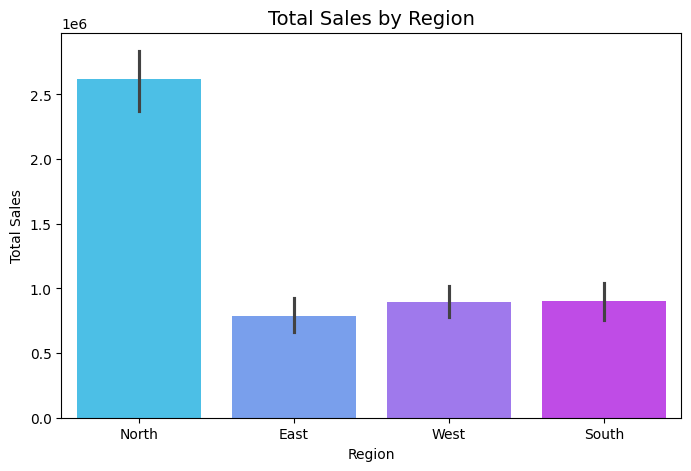

In [178]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpio,x="Region",y="Total Sales",estimator=sum,palette="cool")
plt.title("Total Sales by Region",fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

Text(0, 0.5, 'Total Sales')

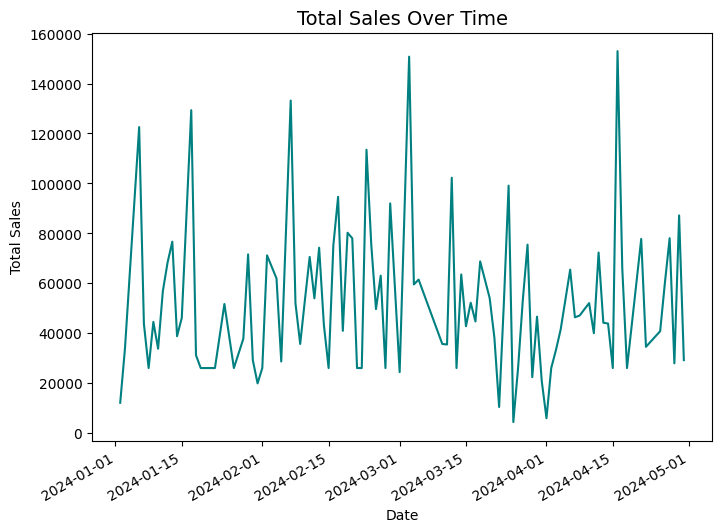

In [179]:
plt.figure(figsize=(8,6))
df_limpio.groupby("Date")["Total Sales"].sum().plot(kind="line",color="teal")
plt.title("Total Sales Over Time",fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")



Tarea 1:
realizar el gratico anterior por region

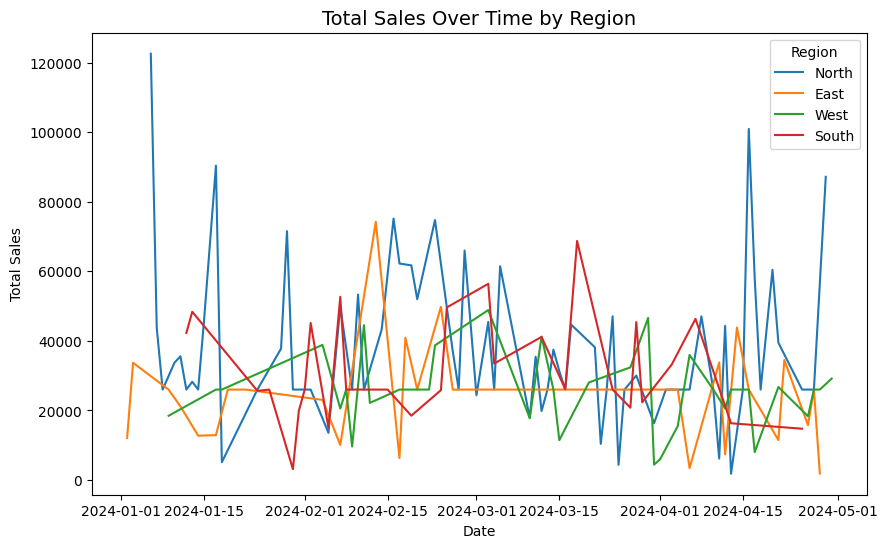

In [180]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df_limpio, x="Date", y="Total Sales", hue="Region", estimator=sum, errorbar=None)
plt.title("Total Sales Over Time by Region", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.show()

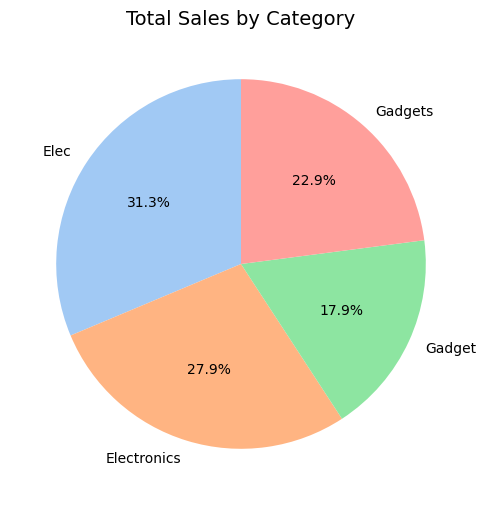

In [181]:
plt.figure(figsize=(6,6))
category_Sales=df_limpio.groupby("Category")["Total Sales"].sum()
category_Sales.plot(kind="pie",autopct="%1.1f%%",startangle=90,colors=sns.color_palette("pastel"))
plt.title("Total Sales by Category",fontsize=14)
plt.ylabel("")
plt.show()

Tarea 2:
unir electronics con elec y gatgets con gatget

tarea 3:
realizar el analisis por producto y región

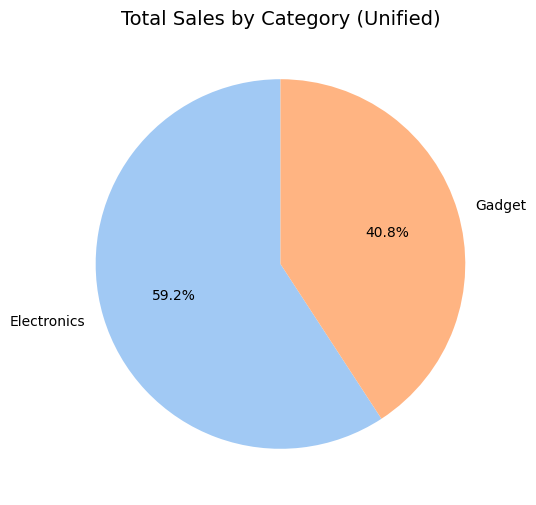

In [182]:
# Tarea 2: Unificar categorías
df_limpio['Category'] = df_limpio['Category'].replace({
    'Elec': 'Electronics',
    'Gadgets': 'Gadget'
})

# Volver a generar el gráfico de pastel con las categorías unificadas
plt.figure(figsize=(6,6))
category_Sales = df_limpio.groupby("Category")["Total Sales"].sum()
category_Sales.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Total Sales by Category (Unified)", fontsize=14)
plt.ylabel("")
plt.show()

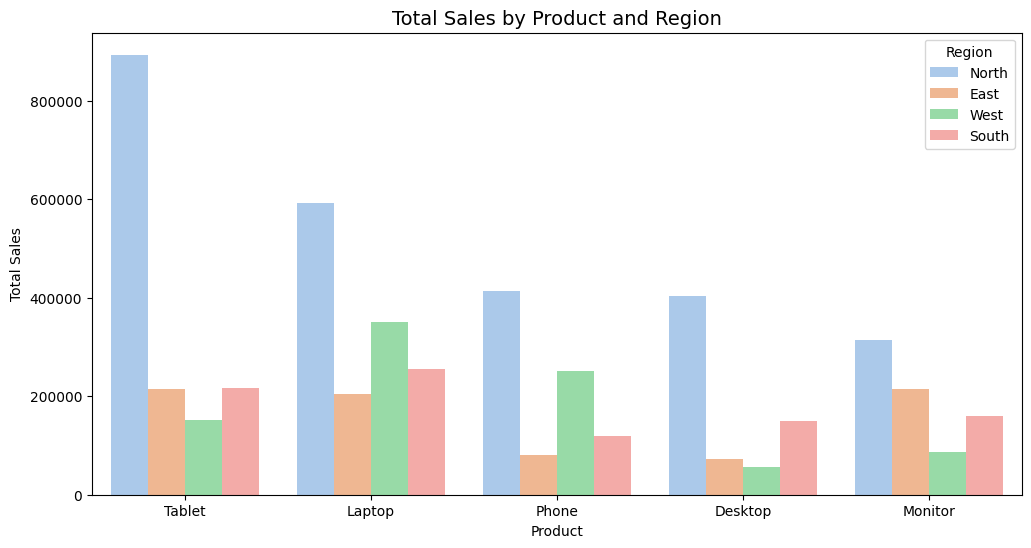

Region,East,North,South,West
Product,,,,
Desktop,73301.142857,403570.571429,149283.428571,57071.000000
Laptop,204661.714286,592258.285714,256036.000000,350382.714286
Monitor,213948.571429,313765.428571,160315.142857,86074.428571
Phone,80938.142857,414151.714286,118711.000000,251869.285714
Tablet,214609.285714,893760.285714,217120.142857,151000.285714


In [183]:
# Tarea 3: Análisis por Producto y Región
plt.figure(figsize=(12, 6))
sns.barplot(data=df_limpio, x="Product", y="Total Sales", hue="Region", estimator=sum, errorbar=None, palette="pastel")
plt.title("Total Sales by Product and Region", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.show()

# Mostrar el resumen de los datos
pivot_resumen = df_limpio.pivot_table(values="Total Sales", index="Product", columns="Region", aggfunc="sum")
display(pivot_resumen)

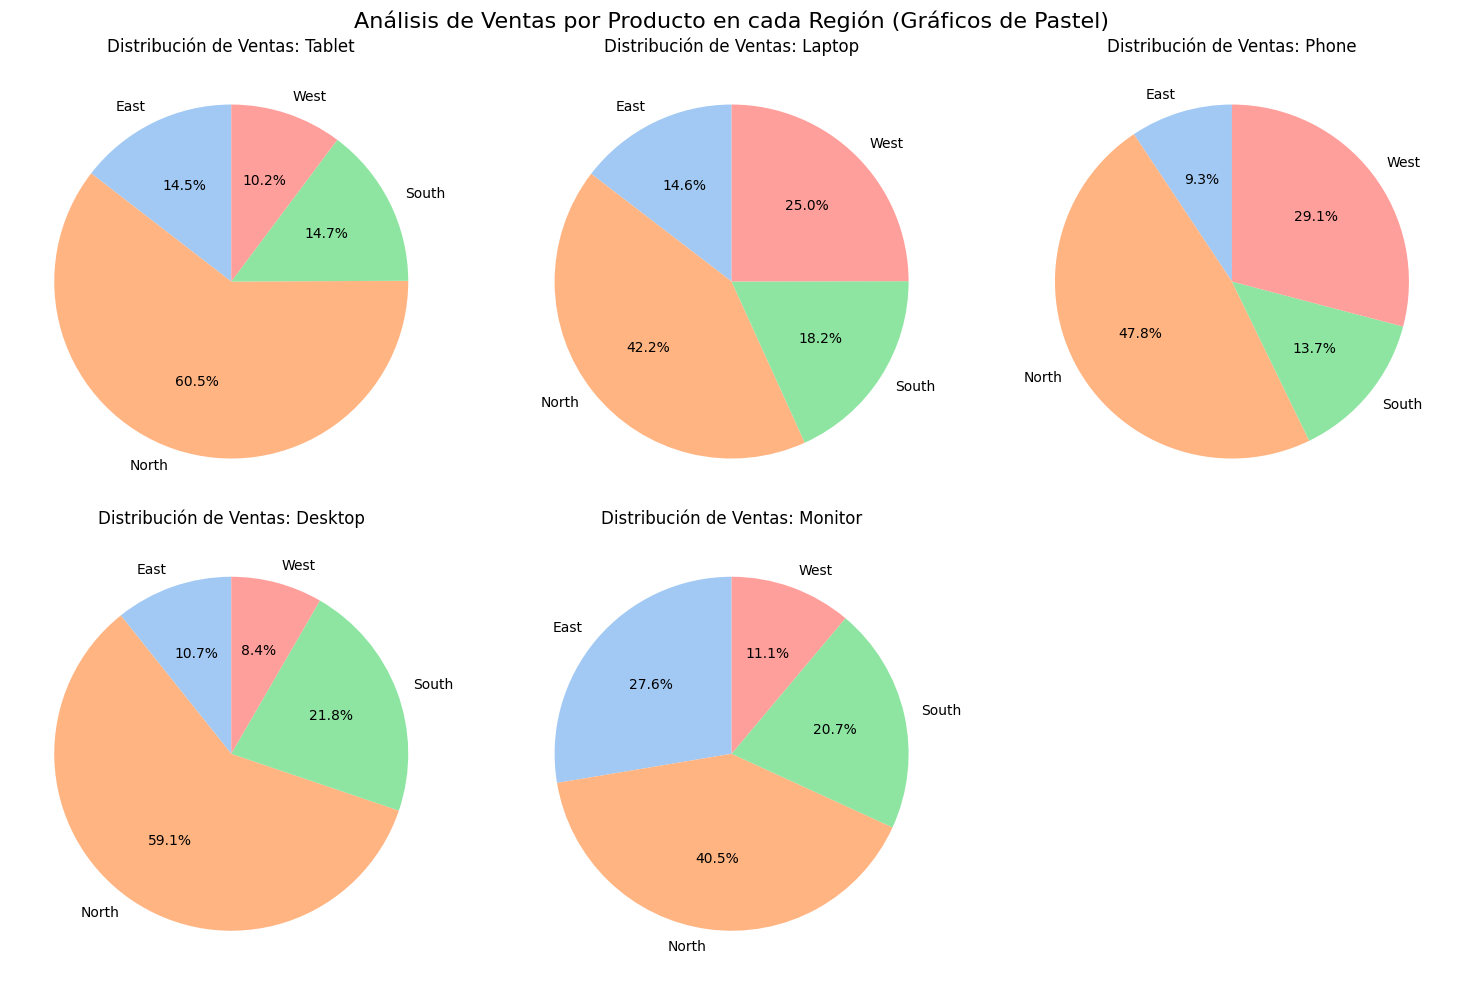

In [184]:
import matplotlib.pyplot as plt
import math

# Obtener la lista de productos únicos
productos = df_limpio['Product'].unique()
num_productos = len(productos)

# Configurar la cuadrícula de subplots de manera dinámica
cols = 3
rows = math.ceil(num_productos / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

# Generar un gráfico de pastel para cada producto
for i, producto in enumerate(productos):
    # Filtrar datos por producto y agrupar por región
    data_producto = df_limpio[df_limpio['Product'] == producto]
    ventas_region = data_producto.groupby('Region')['Total Sales'].sum()

    # Dibujar gráfico de pastel
    axes[i].pie(
        ventas_region,
        labels=ventas_region.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("pastel")
    )
    axes[i].set_title(f"Distribución de Ventas: {producto}", fontsize=12)

# Ocultar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Análisis de Ventas por Producto en cada Región (Gráficos de Pastel)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()